# Practica 04: Analisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudios:** Ingeneria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 20226

### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Daniel Gómez Hernández \
**Matricula:** 230299 \
**Grado y Grupo:** 9°A IEVND 


<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-aling: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.2em; margin: 0;"> Prediccion de Amazon Store - Analisis Exploratorio de Datos Completo y Aprendizaje Automatico Predictivo (ML)</h1>
    <p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Prediccion de Precisos - Analisis de Categorias - Ingenieria de Funcionalidades - Compracion de Modelos</p>
</div>

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerias, carga del CSV, Primeros Comandos de estructura | 

### 1 Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; paffing:12px; border-left:4px solid 3FF9900; border-rafius:5px00; color: #0066cc;">
    
<b>Dataset:</b> Amazon India Listas del productos - 1,436 productos entre Libros,  Kindle, Deporte &  más<br>
    
<b>Objetivo:</b> Predecir el preco del prducto (INR) desde la categoria, logitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-sraped de paginas de productos Amazon.in
    </div>

In [1]:
# ================================================================
# SECTION 1 -Setup & Data Loading
# ================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as ptl
import matplotlib.ticker as mtickr
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f' Pandas : {pd.__version__}')
print(f' NumPy : {np.__version__}')
print(' Todas las librerias cargaron con exito!')

 Pandas : 2.3.3
 NumPy : 2.3.5
 Todas las librerias cargaron con exito!


In [2]:
# Load dataset 
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f' Sahpe   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')
df_raw.head(3)




 Sahpe   : (1447, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


### 2 Diccionario de Datos del Data Frame 📊

In [3]:
# column diccionario 
col_info = {
    'rl'                  : 'URL del Producto en Amazon.in',
    'asin'                : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'                : 'Nombre o Titulo del Producto',
    'overview'            : 'Breve Reseña del Producto (mayoria vacio [])',
    'price'              : 'Presio como String (e.g "1,600.00',
    'currency'            : 'Codigo de Divisa (todas en INR)',
    'availability'        : 'Texto de Statu del Stock (Inventario)',
    'brand'               : 'Nombre de la Marca/Tutor',
    'about_item'          : 'Detalle//Espesificaciones (mayoria faltante)',
    'img_source'          : 'URLs de Imagens del Producto',
    'description'         : 'Descripcion detallada y completa (mayoria faltante)',
    'specifications'      : 'Especificacioes Tecnicas',
    'primary_category'    : 'Categoria Principal (Libros, Kindle, Deportes...)',
    'category_1'          : 'Subcategoria de nivel 1',
    'category_2'          : 'Subcategoria de nivel 2',
    'category_3'          : 'Subcategoria de nivel 3',
    'breadcrumbs'         : 'Ruta de Categorias',

}

print('Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Titulo del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoria vacio [])  | Missing: 0%
 price                | Presio como String (e.g "1,600.00             | Missing: 24%
 currency             | Codigo de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto de Statu del Stock (Inventario)         | Missing: 33%
 brand                | Nombre de la Marca/Tutor                      | Missing: 1%
 about_item           | Detalle//Espesificaciones (mayoria faltante)  | Missing: 92%
 img_source           | URLs de Imagens del Producto                  | Missing: 1%
 description          | Descripcion detallada y completa (mayoria fal | Missing: 92%
 specifications       | Especificacioes Tecni

### 3.Limpieza de Datos

<div style="backgroud:#fffe1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
    <b>Pasos clave para la limpieza:</b><br>
    · Pareseas el precio strings como "1,600.00" → float 1600.0<br>
    · Manejar los datos faltantes (price: 24%, avalability: 33%, description: 92%)<br>
    · Estandarizar el texto de disponibilidad en  categorias limpias<br>
    · Eliminar duplicados
</div>

In [4]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,095 / 1,447 products
✅ Duplicate ASINs: 7
✅ Availability categories: {'In Stock': 607, 'Unknown': 484, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 81, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,[],NaN,Unknown,NaN,2
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


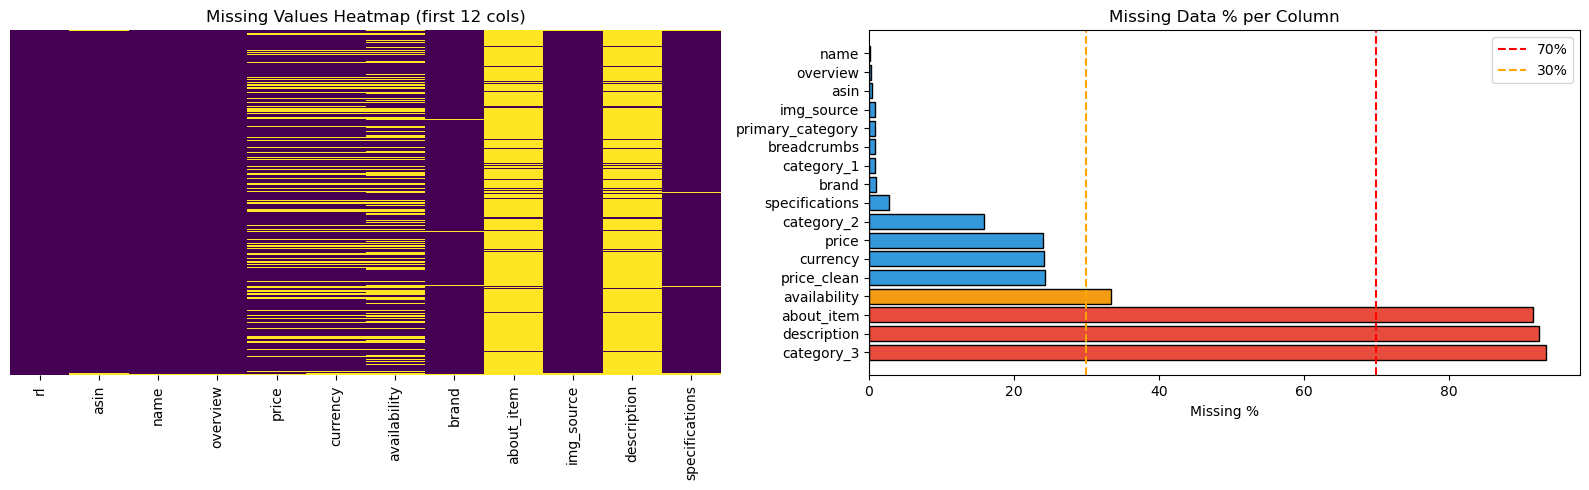

                  Missing Count  Missing Pct
category_3                 1351         93.4
description                1337         92.4
about_item                 1326         91.6
availability                484         33.4
price_clean                 352         24.3
currency                    349         24.1
price                       348         24.0
category_2                  230         15.9
specifications               40          2.8
brand                        14          1.0
category_1                   12          0.8
breadcrumbs                  12          0.8
primary_category             11          0.8
img_source                   11          0.8
asin                          6          0.4
overview                      5          0.3
name                          3          0.2


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resumen de valores faltantes
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap (hasta 12 columnas o las disponibles)
n_cols = min(12, len(df.columns))

sns.heatmap(
    df[df.columns[:n_cols]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title(f'Missing Values Heatmap (first {n_cols} cols)')

# Columnas con valores faltantes
mv = missing[missing['Missing Pct'] > 0]

if not mv.empty:
    colors_mv = [
        '#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
        for v in mv['Missing Pct']
    ]

    axes[1].barh(
        mv.index,
        mv['Missing Pct'],
        color=colors_mv,
        edgecolor='black'
    )

    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].legend()
else:
    axes[1].text(
        0.5, 0.5,
        'No missing values found',
        ha='center',
        va='center',
        fontsize=12
    )

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

plt.tight_layout()
plt.show()

# Imprimir resumen
missing_rows = missing[missing['Missing Count'] > 0]

if not missing_rows.empty:
    print(missing_rows.to_string())
else:
    print("No missing values found.")

### 4. Ingeniería de Características ()

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b> Ejemplo Cotidiano:</b> un agente inmobiliario no solo utiliza los metrso cuadrados brutos, si no tambien consi9dera la ubicacion, la natiguedad y el estado ,
nosotros hacemos lo mismo: extraemos informacion mas valiosa del textor sin procesar y las categorias. 
</div>


In [7]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int) # Esta instruccion imprime laas columnas df enlistadas en este caso Name,
#isbook que hace referecnia al nombre del producto y un boleano si es libro o no.
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de características generadas: {len(df.columns)}')
print('\nDistribución de los rangos de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)



✅ Total de características generadas: 39

Distribución de los rangos de precios:
price_tier
1_budget     106
2_low        285
3_mid        319
4_premium    259
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,[],NaN,Unknown,NaN,0,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Analisis Universal 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Key question:</b> What does the price distribution look like? Are there outliers? Is the data skewed?
</div>

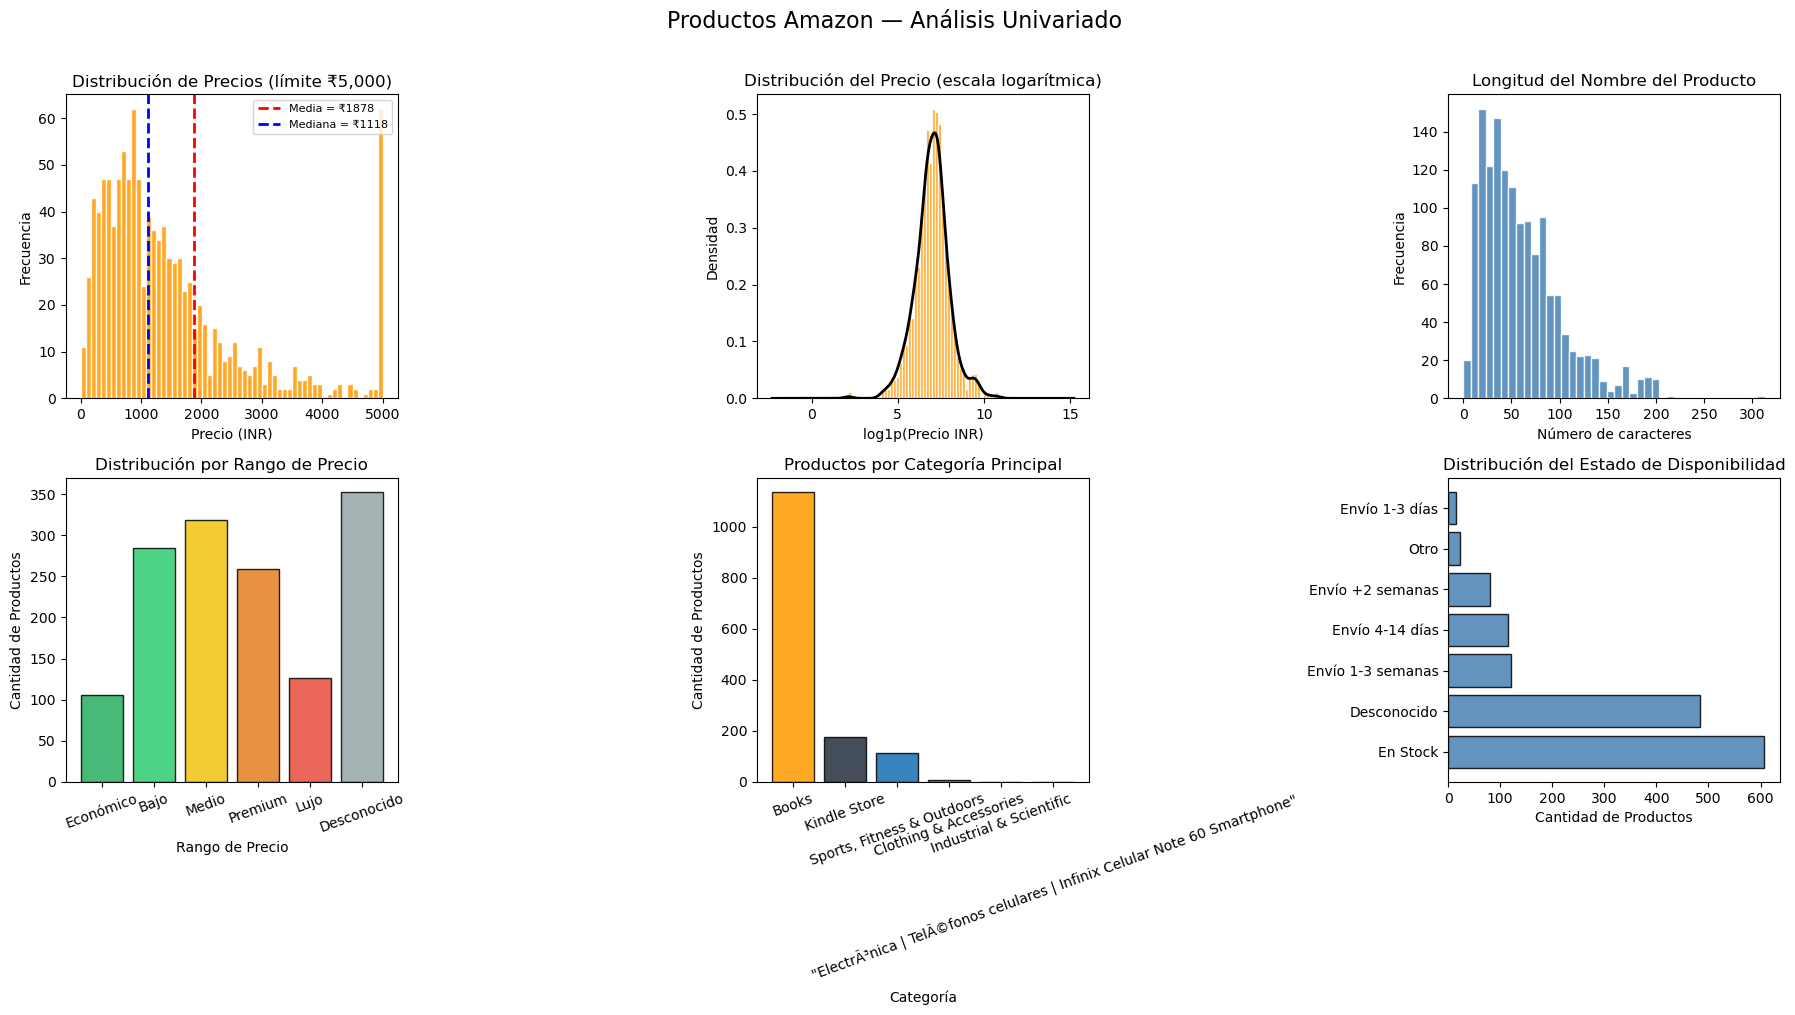

Prueba Shapiro-Wilk (precio logarítmico, n=500)
Estadístico = 0.9796, p-valor = 0.000002
La distribución del precio sigue sin ser normal después de la transformación logarítmica.

Estadísticas descriptivas del precio (INR):
count     1088.00
mean      1877.87
std       3338.95
min          7.00
25%        608.50
50%       1117.50
75%       1850.00
max      50555.00


In [11]:
# ============================================================
# SECTION 4 — Análisis Univariado
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import shapiro

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribución de precios
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red', linestyle='--', lw=2,
    label=f'Media = ₹{df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue', linestyle='--', lw=2,
    label=f'Mediana = ₹{df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Distribución de Precios (límite ₹5,000)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=8)

# Distribución logarítmica del precio
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)

axes[0,1].set_title('Distribución del Precio (escala logarítmica)')
axes[0,1].set_xlabel('log1p(Precio INR)')
axes[0,1].set_ylabel('Densidad')

# Longitud del nombre del producto
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Longitud del Nombre del Producto')
axes[0,2].set_xlabel('Número de caracteres')
axes[0,2].set_ylabel('Frecuencia')

# Rangos de precio
tier_counts = df['price_tier'].value_counts().sort_index()

# Traducción de categorías de precio
tier_labels = {
    '1_budget': 'Económico',
    '2_low': 'Bajo',
    '3_mid': 'Medio',
    '4_premium': 'Premium',
    '5_luxury': 'Lujo',
    'Unknown': 'Desconocido'
}

tier_counts.index = [tier_labels.get(x, x) for x in tier_counts.index]

tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Distribución por Rango de Precio')
axes[1,0].set_xlabel('Rango de Precio')
axes[1,0].set_ylabel('Cantidad de Productos')
axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_xlabel('Categoría')
axes[1,1].set_ylabel('Cantidad de Productos')
axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()

# Traducción de estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 weeks': 'Envío 1-3 semanas',
    'Ships 2+ weeks': 'Envío +2 semanas',
    'Ships 4-14 days': 'Envío 4-14 días',
    'Ships 1-3 days': 'Envío 1-3 días',
    'Other': 'Otro'
}

avail_counts.index = [
    avail_translation.get(x, x)
    for x in avail_counts.index
]

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad de Productos')

plt.suptitle(
    'Productos Amazon — Análisis Univariado',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Prueba de normalidad
# --------------------------------------------------
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

print(f'Prueba Shapiro-Wilk (precio logarítmico, n=500)')
print(f'Estadístico = {stat:.4f}, p-valor = {p:.6f}')

if p > 0.05:
    print('La distribución del precio puede considerarse normal después de la transformación logarítmica.')
else:
    print('La distribución del precio sigue sin ser normal después de la transformación logarítmica.')

print('\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())


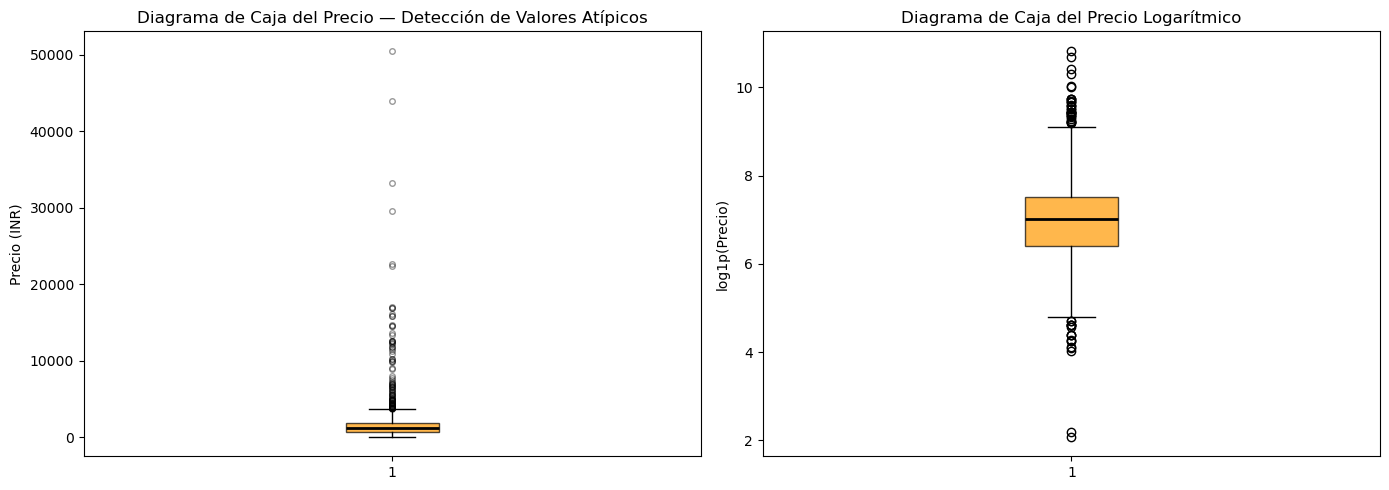

ANÁLISIS DE VALORES ATÍPICOS MEDIANTE IQR
Valores atípicos detectados (método IQR): 93 (8.5%)
Rango de precios sin valores atípicos: ₹-1254 – ₹3712

LOS 10 PRODUCTOS MÁS CAROS
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films

In [13]:
# ============================================================
# Análisis de Valores Atípicos (Outliers) — Boxplot e IQR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de precios originales
axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')
)

axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

# Boxplot de precios transformados con logaritmo
axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

# ============================================================
# Método IQR para detección de valores atípicos
# ============================================================

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

print("=" * 60)
print("ANÁLISIS DE VALORES ATÍPICOS MEDIANTE IQR")
print("=" * 60)

print(
    f"Valores atípicos detectados (método IQR): "
    f"{len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)"
)

print(
    f"Rango de precios sin valores atípicos: "
    f"₹{Q1 - 1.5*IQR:.0f} – ₹{Q3 + 1.5*IQR:.0f}"
)

print("\n" + "=" * 60)
print("LOS 10 PRODUCTOS MÁS CAROS")
print("=" * 60)

print(
    df_priced
    .nlargest(10, 'price_clean')
    [['name', 'price_clean', 'primary_category']]
    .to_string(index=False)
)

## 6. Análisis de categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías dominan? ¿Dónde está el mayor valor?
</div>

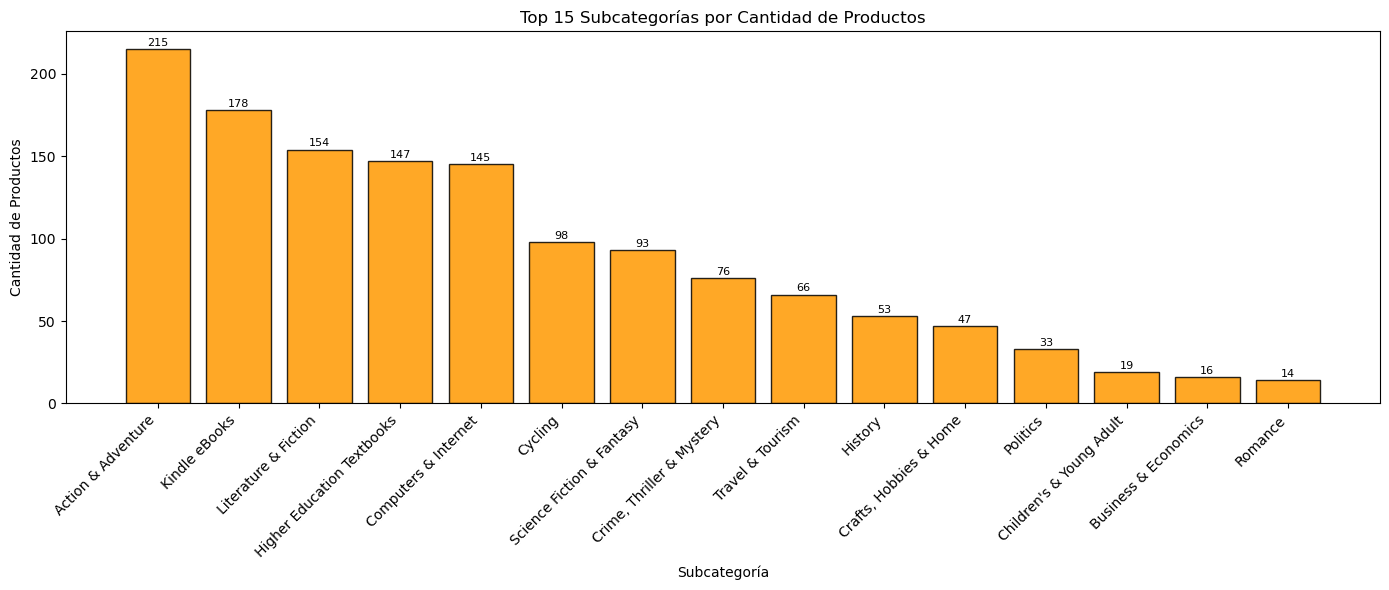

In [12]:
# ============================================================
# SECTION 5 — Análisis de Categorías
# ============================================================

# Top 15 subcategorías con más productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    top15_cat1.index,
    top15_cat1.values,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

# Etiquetas de cantidad sobre cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Subcategoría')
plt.ylabel('Cantidad de Productos')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

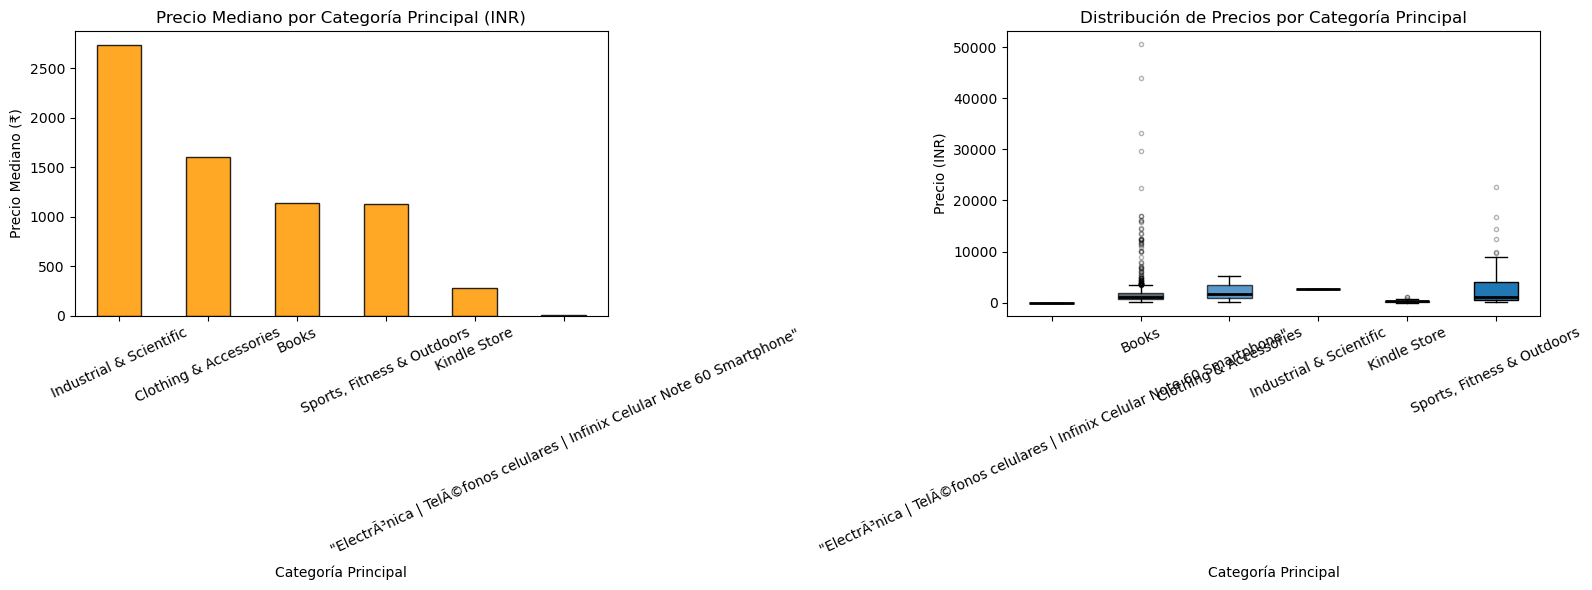


ESTADÍSTICAS DE PRECIOS POR CATEGORÍA PRINCIPAL
                                                                             Precio Promedio  Precio Mediano  Cantidad de Productos
primary_category                                                                                                                   
 "ElectrÃ³nica | TelÃ©fonos celulares | Infinix Celular Note 60 Smartphone"              8.0             8.0                      1
Books                                                                                 1825.8          1143.5                    954
Clothing & Accessories                                                                2249.2          1606.5                      6
Industrial & Scientific                                                               2738.0          2738.0                      1
Kindle Store                                                                           350.0           281.4                     30
Sports, Fitness & Outdoors 

In [17]:
# ============================================================
# Precio por Categoría Principal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Estadísticas por categoría
# --------------------------------------------------

cat_price = (
    df_priced
    .groupby('primary_category')['price_clean']
    .agg(['mean', 'median', 'count'])
    .round(1)
)

# --------------------------------------------------
# Gráfico de barras (Precio mediano)
# --------------------------------------------------

cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_xlabel('Categoría Principal')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=25)

# --------------------------------------------------
# Boxplot de distribución de precios
# --------------------------------------------------

cat_groups = [
    df_priced[
        df_priced['primary_category'] == categoria
    ]['price_clean'].dropna()
    for categoria in cat_price.index
]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,  # ← evita el warning
    patch_artist=True,
    medianprops=dict(
        color='black',
        lw=2
    ),
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.3
    )
)

colors_cat = [
    '#FF9900',
    '#232F3E',
    '#146EB4',
    '#E47911',
    '#999999'
]

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_xlabel('Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

# ============================================================
# Tabla de estadísticas
# ============================================================

cat_price_es = cat_price.rename(columns={
    'mean': 'Precio Promedio',
    'median': 'Precio Mediano',
    'count': 'Cantidad de Productos'
})

print("\n" + "="*70)
print("ESTADÍSTICAS DE PRECIOS POR CATEGORÍA PRINCIPAL")
print("="*70)

print(cat_price_es.to_string())

# ============================================================
# Resumen adicional
# ============================================================

categoria_mas_cara = cat_price['median'].idxmax()
precio_mas_alto = cat_price['median'].max()

categoria_mas_barata = cat_price['median'].idxmin()
precio_mas_bajo = cat_price['median'].min()

print("\n" + "="*70)
print("RESUMEN")
print("="*70)

print(
    f"Categoría con mayor precio mediano: "
    f"{categoria_mas_cara} (₹{precio_mas_alto:,.0f})"
)

print(
    f"Categoría con menor precio mediano: "
    f"{categoria_mas_barata} (₹{precio_mas_bajo:,.0f})"
)

print(
    f"Número total de categorías analizadas: "
    f"{len(cat_price)}"
)

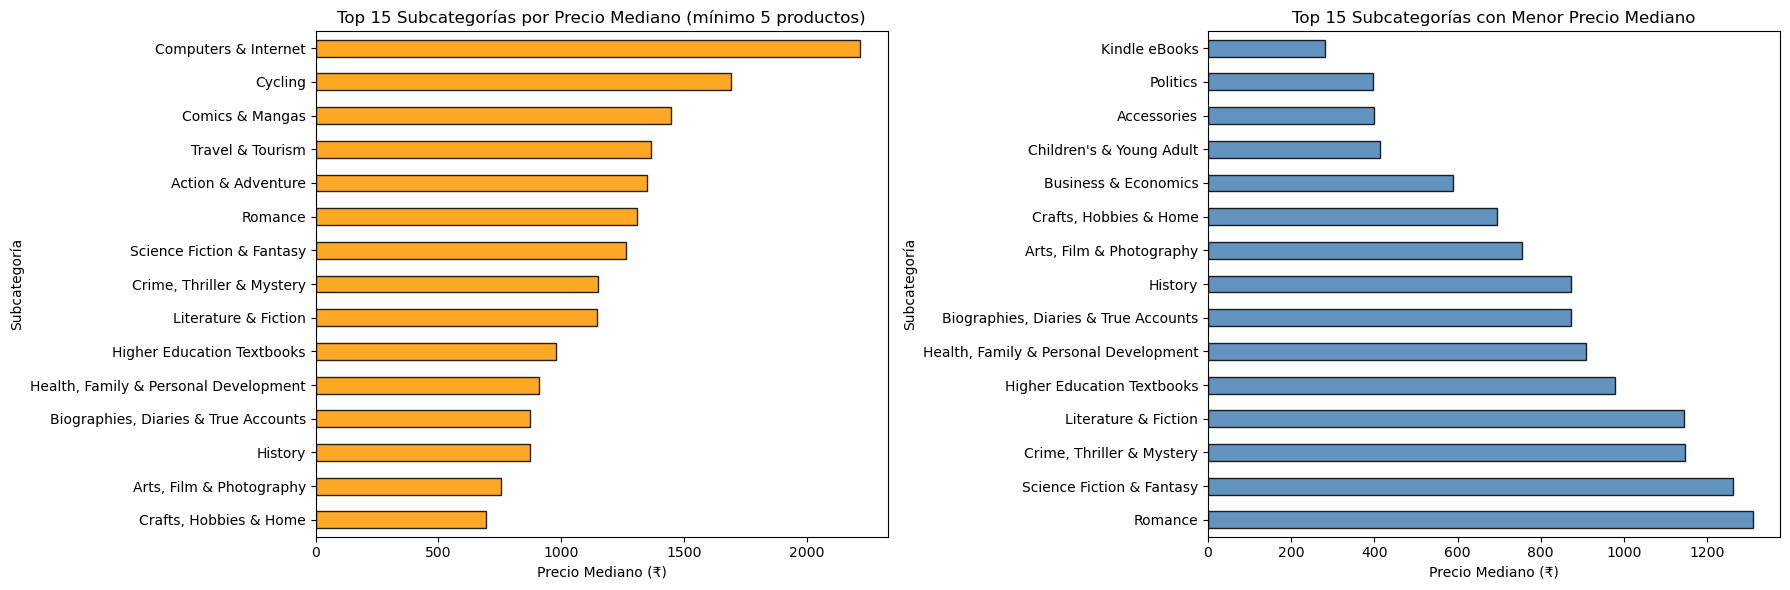

In [19]:
# ============================================================
# Top 15 Subcategorías por Precio Mediano
# ============================================================

top_cat1_price = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --------------------------------------------------
# 15 subcategorías más caras
# --------------------------------------------------

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title(
    'Top 15 Subcategorías por Precio Mediano (mínimo 5 productos)'
)
axes[0].set_xlabel('Precio Mediano (₹)')
axes[0].set_ylabel('Subcategoría')

# --------------------------------------------------
# 15 subcategorías más económicas
# --------------------------------------------------

bottom_cat1 = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title(
    'Top 15 Subcategorías con Menor Precio Mediano'
)
axes[1].set_xlabel('Precio Mediano (₹)')
axes[1].set_ylabel('Subcategoría')

plt.tight_layout()
plt.show()

## 7. Availability Analysis 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿El estado de disponibilidad afecta el precio? ¿Es más probable que los productos premium se agoten?
</div>

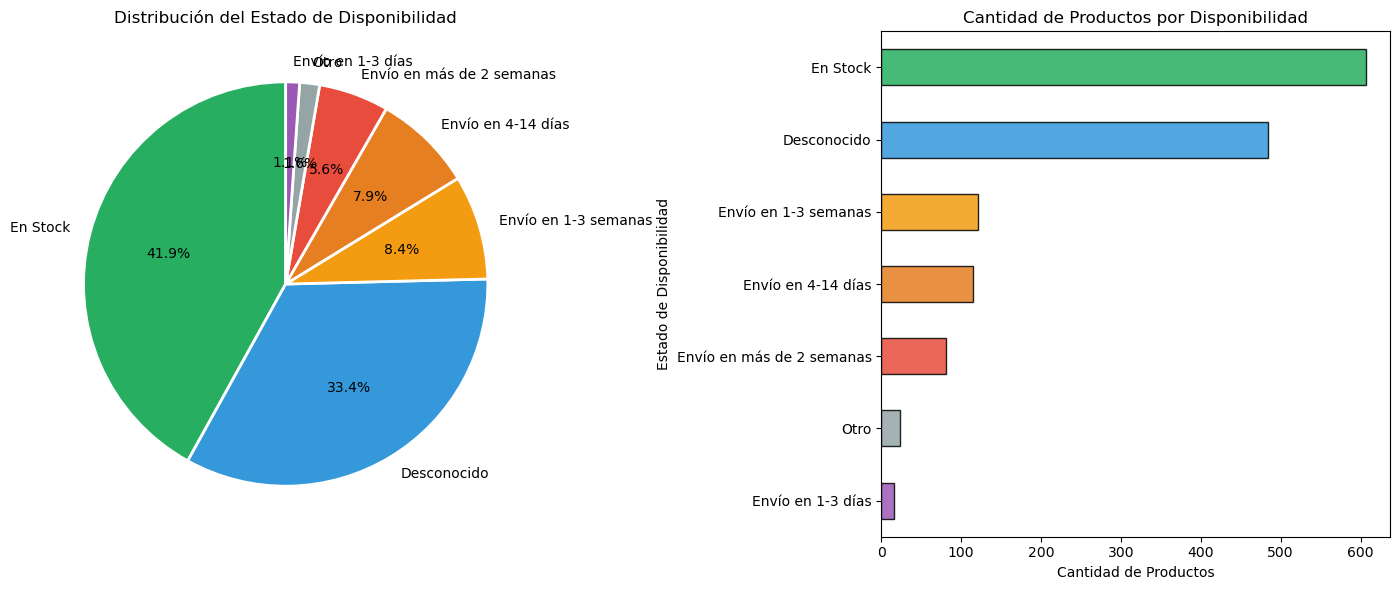

In [20]:
# ============================================================
# SECTION 6 — Análisis de Disponibilidad
# ============================================================

# Traducir estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 days': 'Envío en 1-3 días',
    'Ships 4-14 days': 'Envío en 4-14 días',
    'Ships 1-3 weeks': 'Envío en 1-3 semanas',
    'Ships 2+ weeks': 'Envío en más de 2 semanas',
    'Other': 'Otro'
}

avail_counts = df['avail_clean'].value_counts()

# Aplicar traducción a las etiquetas
avail_counts.index = [
    avail_translation.get(x, x)
    for x in avail_counts.index
]

avail_colors = [
    '#27ae60',
    '#3498db',
    '#f39c12',
    '#e67e22',
    '#e74c3c',
    '#95a5a6',
    '#9b59b6',
    '#1abc9c'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------------
# Gráfico circular
# --------------------------------------------------

axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(
        edgecolor='white',
        linewidth=2
    )
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

# --------------------------------------------------
# Gráfico de barras horizontal
# --------------------------------------------------

avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad de Productos por Disponibilidad')
axes[1].set_xlabel('Cantidad de Productos')
axes[1].set_ylabel('Estado de Disponibilidad')

plt.tight_layout()
plt.show()

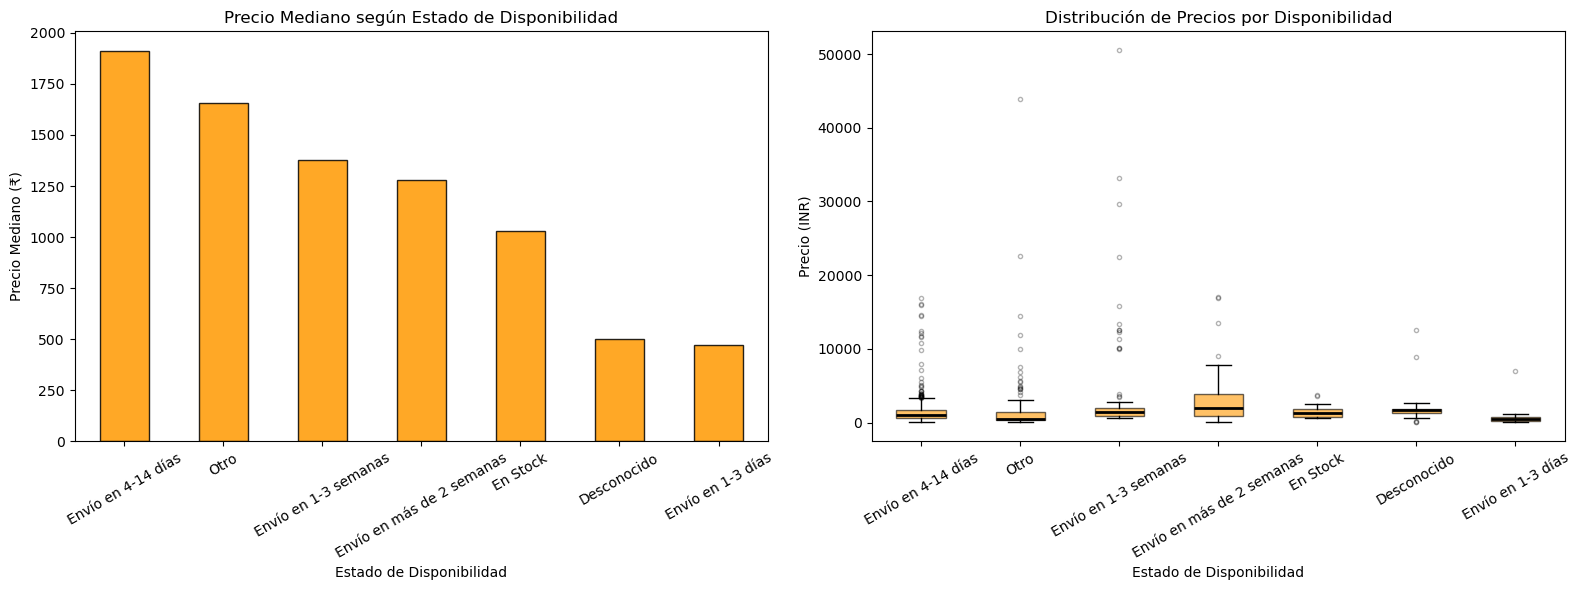


ESTADÍSTICAS DE PRECIO SEGÚN DISPONIBILIDAD
                           Precio Mediano  Precio Promedio  Cantidad de Productos
Envío en 4-14 días                 1912.3           2874.6                    115
Otro                               1659.0           2241.1                     22
Envío en 1-3 semanas               1377.0           3231.6                    121
Envío en más de 2 semanas          1279.0           1398.4                     81
En Stock                           1030.0           1490.5                    599
Desconocido                         502.0           1881.5                    134
Envío en 1-3 días                   469.0            874.9                     16


In [23]:
# ============================================================
# Precio según Estado de Disponibilidad
# ============================================================

# Traducción de estados de disponibilidad
avail_translation = {
    'In Stock': 'En Stock',
    'Unknown': 'Desconocido',
    'Ships 1-3 days': 'Envío en 1-3 días',
    'Ships 4-14 days': 'Envío en 4-14 días',
    'Ships 1-3 weeks': 'Envío en 1-3 semanas',
    'Ships 2+ weeks': 'Envío en más de 2 semanas',
    'Other': 'Otro'
}

avail_price = (
    df_priced
    .groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

# Traducir índices
avail_price.index = [
    avail_translation.get(x, x)
    for x in avail_price.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Gráfico de barras
# --------------------------------------------------

avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano según Estado de Disponibilidad')
axes[0].set_xlabel('Estado de Disponibilidad')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=30)

# --------------------------------------------------
# Boxplot
# --------------------------------------------------

avail_groups = [
    df_priced[
        df_priced['avail_clean'] == estado_original
    ]['price_clean'].dropna()
    for estado_original in (
        df_priced['avail_clean']
        .value_counts()
        .index
        .intersection(
            [k for k, v in avail_translation.items()
             if v in avail_price.index]
        )
    )
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(
        color='black',
        lw=2
    ),
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.3
    )
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ============================================================
# Tabla de resultados
# ============================================================

avail_price_es = avail_price.rename(columns={
    'median': 'Precio Mediano',
    'mean': 'Precio Promedio',
    'count': 'Cantidad de Productos'
})

print("\n" + "="*70)
print("ESTADÍSTICAS DE PRECIO SEGÚN DISPONIBILIDAD")
print("="*70)

print(avail_price_es.to_string())


## 8. Correlation & Bivariate Analysis 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b> Pregunta clave: </b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>


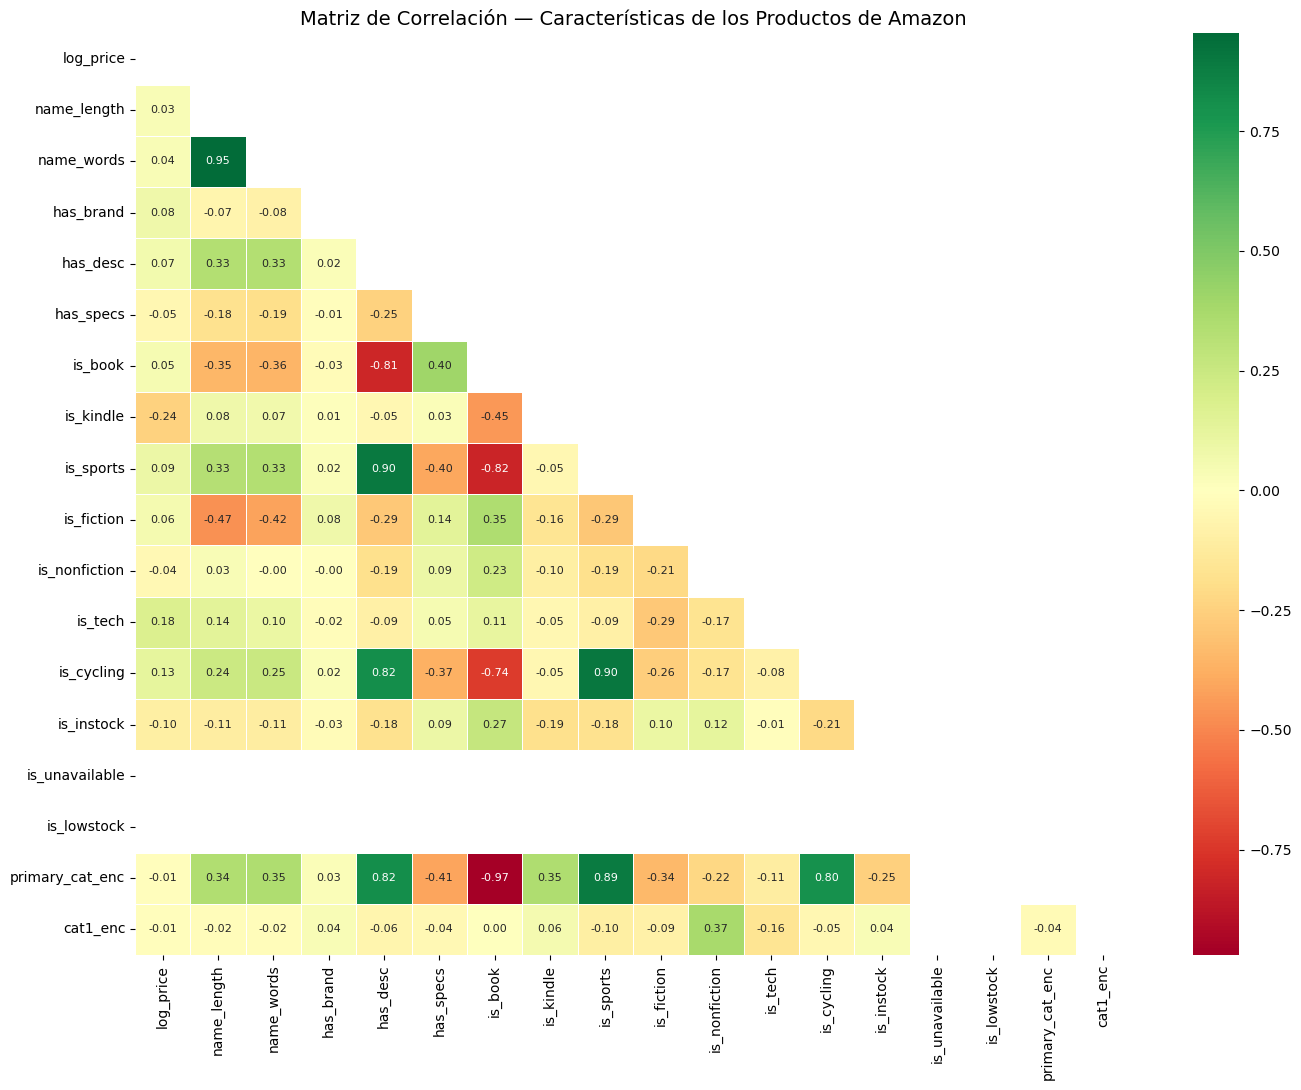


CORRELACIONES MÁS IMPORTANTES CON EL PRECIO
is_tech            0.176046
is_cycling         0.126940
is_sports          0.092698
has_brand          0.082140
has_desc           0.065556
is_fiction         0.058535
is_book            0.050968
name_words         0.035443
name_length        0.030477
primary_cat_enc   -0.010385
cat1_enc          -0.012391
is_nonfiction     -0.039664
has_specs         -0.046761
is_instock        -0.104767
is_kindle         -0.242271
is_unavailable          NaN
is_lowstock             NaN


In [24]:
# ============================================================
# SECTION 7 — Análisis de Correlación
# ============================================================

corr_cols = [
    'log_price',
    'name_length',
    'name_words',
    'has_brand',
    'has_desc',
    'has_specs',
    'is_book',
    'is_kindle',
    'is_sports',
    'is_fiction',
    'is_nonfiction',
    'is_tech',
    'is_cycling',
    'is_instock',
    'is_unavailable',
    'is_lowstock',
    'primary_cat_enc',
    'cat1_enc'
]

corr = df_priced[corr_cols].corr()

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title(
    'Matriz de Correlación — Características de los Productos de Amazon',
    fontsize=14
)

plt.tight_layout()
plt.show()

# ============================================================
# Correlaciones con el precio
# ============================================================

print("\n" + "="*70)
print("CORRELACIONES MÁS IMPORTANTES CON EL PRECIO")
print("="*70)

corr_log_price = (
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

print(corr_log_price.to_string())

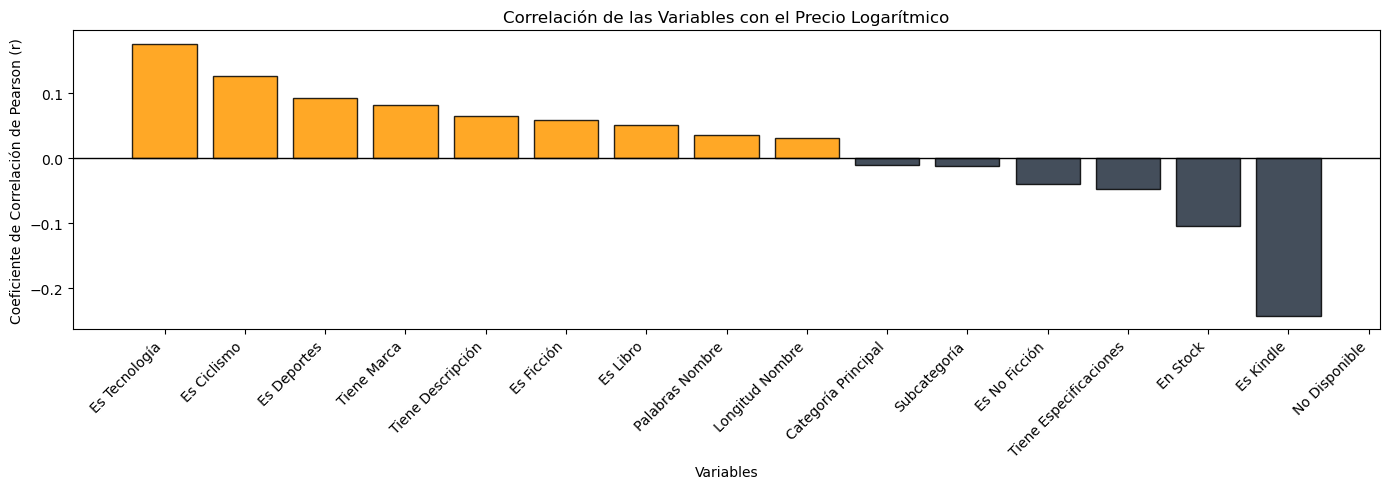

In [25]:
# ============================================================
# Gráfico de Correlación de Variables con el Precio
# ============================================================

# Correlaciones con el precio logarítmico
feat_corr = (
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

# Traducción de nombres de variables
corr_labels = {
    'name_length': 'Longitud Nombre',
    'name_words': 'Palabras Nombre',
    'has_brand': 'Tiene Marca',
    'has_desc': 'Tiene Descripción',
    'has_specs': 'Tiene Especificaciones',
    'is_book': 'Es Libro',
    'is_kindle': 'Es Kindle',
    'is_sports': 'Es Deportes',
    'is_fiction': 'Es Ficción',
    'is_nonfiction': 'Es No Ficción',
    'is_tech': 'Es Tecnología',
    'is_cycling': 'Es Ciclismo',
    'is_instock': 'En Stock',
    'is_unavailable': 'No Disponible',
    'is_lowstock': 'Stock Bajo',
    'primary_cat_enc': 'Categoría Principal',
    'cat1_enc': 'Subcategoría'
}

feat_corr.index = [
    corr_labels.get(x, x)
    for x in feat_corr.index
]

# Colores según el signo de la correlación
colors_fc = [
    '#FF9900' if valor > 0 else '#232F3E'
    for valor in feat_corr.values
]

plt.figure(figsize=(14, 5))

plt.bar(
    feat_corr.index,
    feat_corr.values,
    color=colors_fc,
    edgecolor='black',
    alpha=0.85
)

plt.axhline(
    0,
    color='black',
    lw=1
)

plt.title(
    'Correlación de las Variables con el Precio Logarítmico'
)

plt.ylabel('Coeficiente de Correlación de Pearson (r)')
plt.xlabel('Variables')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

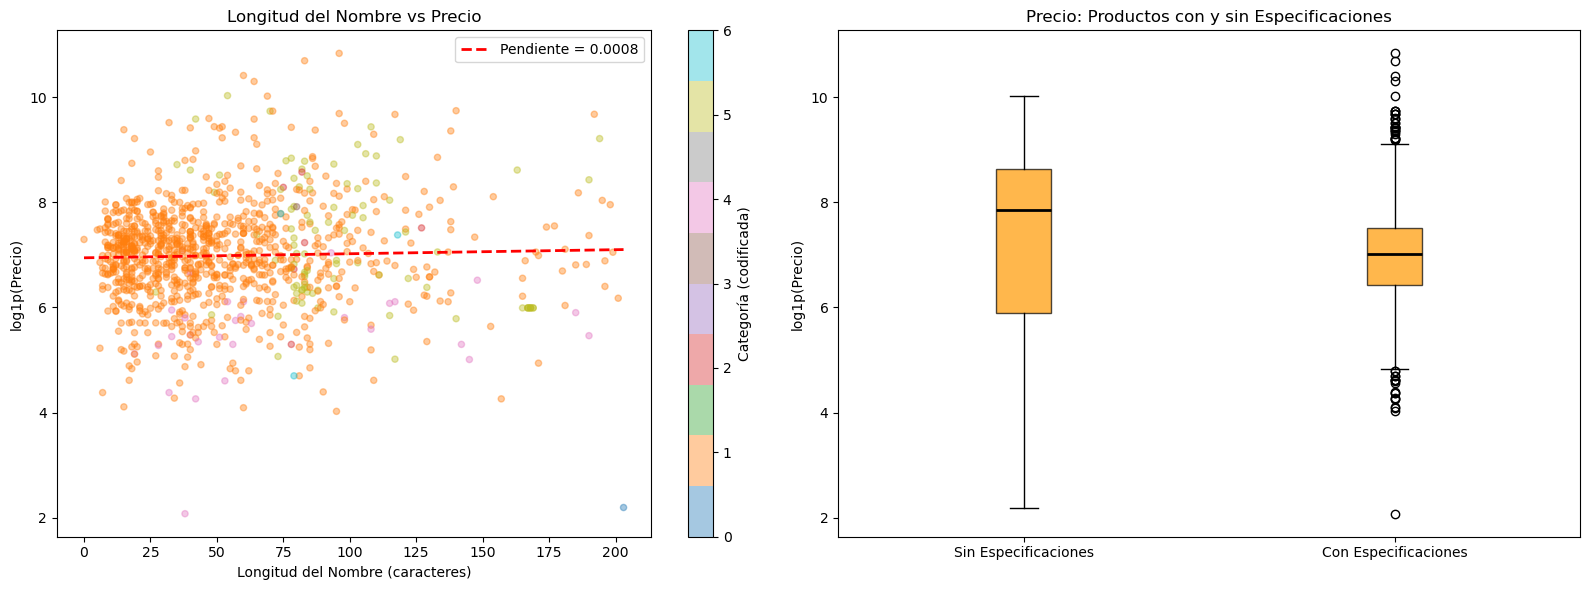

In [26]:
# ============================================================
# Relación entre Longitud del Nombre y Precio
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------------
# Gráfico de dispersión
# --------------------------------------------------

sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(
    sc,
    ax=axes[0],
    label='Categoría (codificada)'
)

# Línea de tendencia
m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(
    0,
    df_priced['name_length'].max(),
    100
)

axes[0].plot(
    x,
    m * x + b,
    'r--',
    lw=2,
    label=f'Pendiente = {m:.4f}'
)

axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio')
axes[0].legend()

# --------------------------------------------------
# Precio según existencia de especificaciones
# --------------------------------------------------

axes[1].boxplot(
    [
        np.log1p(
            df_priced[df_priced['has_specs'] == 0]['price_clean']
        ),
        np.log1p(
            df_priced[df_priced['has_specs'] == 1]['price_clean']
        )
    ],
    tick_labels=[
        'Sin Especificaciones',
        'Con Especificaciones'
    ],
    patch_artist=True,
    boxprops=dict(
        facecolor='#FF9900',
        alpha=0.7
    ),
    medianprops=dict(
        color='black',
        lw=2
    )
)

axes[1].set_title(
    'Precio: Productos con y sin Especificaciones'
)

axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()